# Price Optimization & Elasticity Analysis

## 💰 Business Context

Pricing is one of the most powerful levers for profitability. Setting the right price requires understanding how demand changes with price (elasticity). This analysis estimates price elasticity for different products and determines the optimal price point to maximize revenue or profit.

## 📊 Objectives

1. Estimate Price Elasticity of Demand (PED) using regression
2. Classify products as Elastic, Inelastic, or Unitary
3. Model Revenue and Profit curves
4. Determine the optimal price point for maximum profitability
5. Simulate the impact of price changes

## 🔧 Methodology

- **Data**: Synthetic sales data with varying price points
- **Techniques**: Log-Log Regression (for constant elasticity), Linear Regression, Optimization
- **Metrics**: Elasticity Coefficient, Optimal Price, Revenue Lift

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('rocket')
%matplotlib inline

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


## 1. Data Generation

Simulating sales data for a product at different price points over time.

In [2]:
def generate_pricing_data(n=365):
    np.random.seed(42)
    dates = pd.date_range(start='2023-01-01', periods=n, freq='D')
    
    # Base Demand Parameters
    # Demand = Intercept * Price^Elasticity
    # Log(Demand) = Log(Intercept) + Elasticity * Log(Price)
    
    intercept = 10000
    true_elasticity = -1.5 # Elastic demand (sensitive to price)
    
    # Varying Price Strategy (Random fluctuations + Strategy changes)
    base_price = 50
    price = np.random.normal(base_price, 5, n)
    price = np.clip(price, 30, 80)
    
    # Generate Demand with noise
    demand = intercept * (price ** true_elasticity)
    demand = demand * np.random.normal(1, 0.1, n) # 10% noise
    
    # Cost per unit (Fixed)
    cost = 25
    
    df = pd.DataFrame({
        'Date': dates,
        'Price': price,
        'Demand': demand.astype(int),
        'Unit_Cost': cost
    })
    
    df['Revenue'] = df['Price'] * df['Demand']
    df['Profit'] = (df['Price'] - df['Unit_Cost']) * df['Demand']
    
    return df

df = generate_pricing_data()
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (365, 6)


,Date,Price,Demand,Unit_Cost,Revenue,Profit
0,2023-01-01,52.483571,25,25,1312.089269,687.089269
1,2023-01-02,49.308678,29,25,1429.951676,704.951676
2,2023-01-03,53.238443,25,25,1330.961067,705.961067
3,2023-01-04,57.615149,23,25,1325.148433,750.148433
4,2023-01-05,48.829233,27,25,1318.389294,643.389294


## 2. Exploratory Data Analysis

Visualizing the Price-Demand relationship.

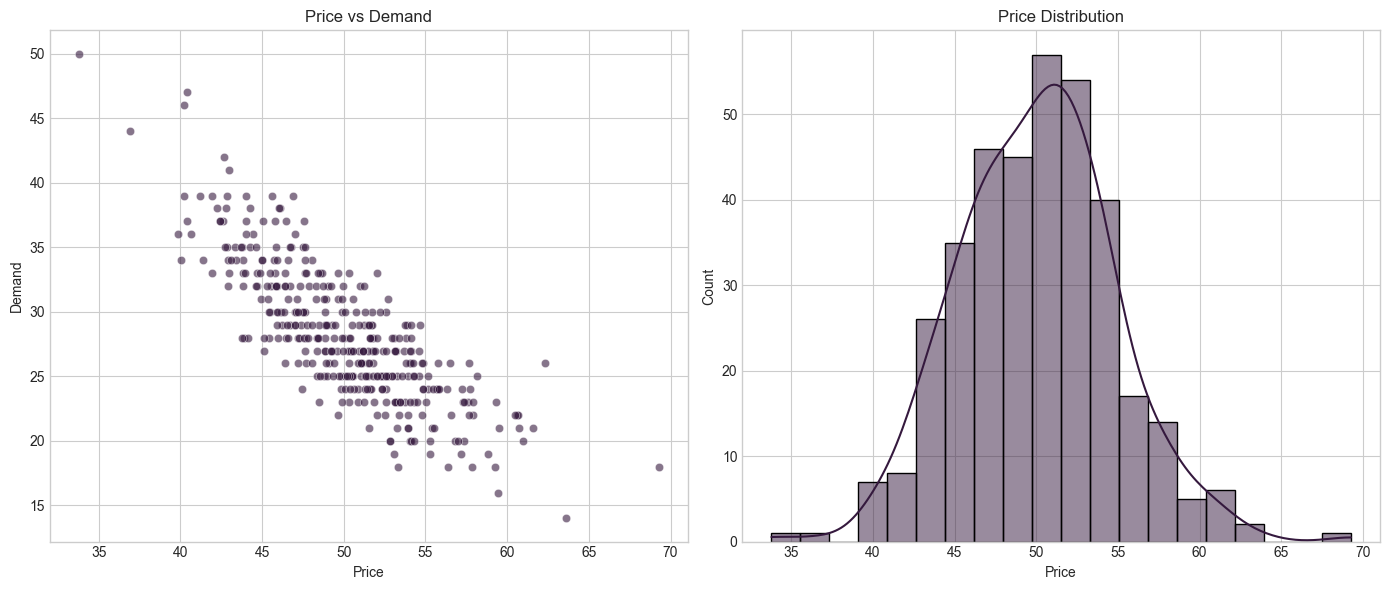

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Price vs Demand Scatter
sns.scatterplot(x='Price', y='Demand', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Price vs Demand')

# Price Distribution
sns.histplot(df['Price'], kde=True, ax=axes[1])
axes[1].set_title('Price Distribution')

plt.tight_layout()
plt.savefig('outputs/price_demand_eda.png')
plt.show()

## 3. Estimating Price Elasticity

Using Log-Log Regression to estimate constant elasticity.

In [4]:
# Log-transform variables
df['Log_Price'] = np.log(df['Price'])
df['Log_Demand'] = np.log(df['Demand'])

# Fit OLS Model
X = sm.add_constant(df['Log_Price'])
y = df['Log_Demand']

model = sm.OLS(y, X).fit()

elasticity = model.params['Log_Price']
intercept_log = model.params['const']
intercept_val = np.exp(intercept_log)

print(model.summary())
print("="*60)
print(f"Estimated Price Elasticity: {elasticity:.2f}")

if elasticity < -1:
    print("Interpretation: Demand is ELASTIC (sensitive to price changes).")
elif elasticity > -1:
    print("Interpretation: Demand is INELASTIC (insensitive to price changes).")
else:
    print("Interpretation: Demand is UNITARY elastic.")

                            OLS Regression Results                            
Dep. Variable:             Log_Demand   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     763.3
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           2.84e-91
Time:                        05:51:40   Log-Likelihood:                 301.07
No. Observations:                 365   AIC:                            -598.1
Df Residuals:                     363   BIC:                            -590.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.6380      0.229     42.135      0.0

## 4. Revenue & Profit Optimization

Modeling the theoretical curves to find the peak.

Optimal Price for Revenue: $20.00
Optimal Price for Profit: $65.25


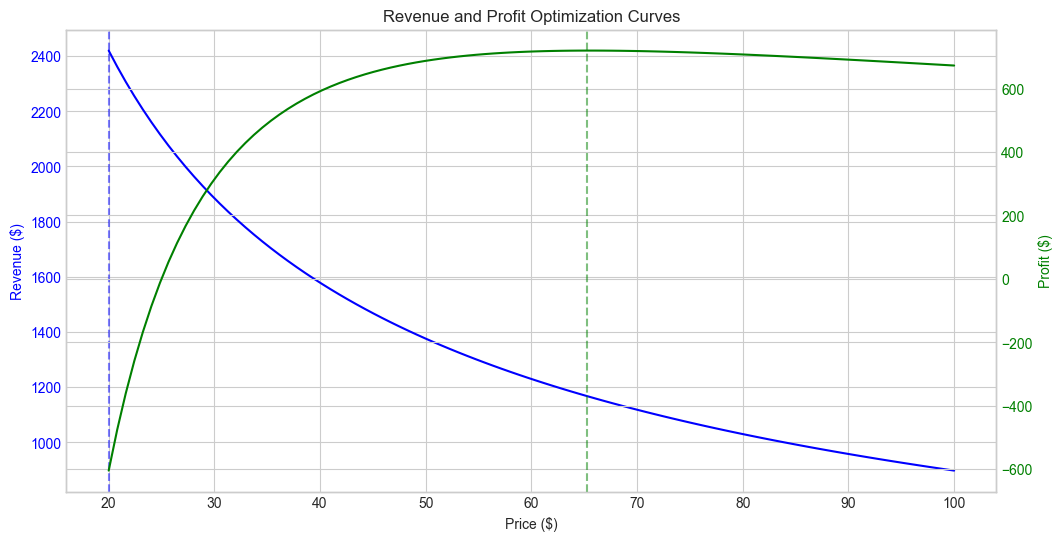

In [5]:
# Define range of potential prices
price_range = np.linspace(20, 100, 100)

# Predict Demand
pred_demand = intercept_val * (price_range ** elasticity)

# Calculate Revenue and Profit
pred_revenue = price_range * pred_demand
pred_profit = (price_range - df['Unit_Cost'].mean()) * pred_demand

# Find Optima
optimal_price_rev = price_range[np.argmax(pred_revenue)]
optimal_price_prof = price_range[np.argmax(pred_profit)]

print(f"Optimal Price for Revenue: ${optimal_price_rev:.2f}")
print(f"Optimal Price for Profit: ${optimal_price_prof:.2f}")

# Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(price_range, pred_revenue, 'b-', label='Revenue')
ax1.set_xlabel('Price ($)')
ax1.set_ylabel('Revenue ($)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.axvline(optimal_price_rev, color='b', linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(price_range, pred_profit, 'g-', label='Profit')
ax2.set_ylabel('Profit ($)', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.axvline(optimal_price_prof, color='g', linestyle='--', alpha=0.5)

plt.title('Revenue and Profit Optimization Curves')
plt.savefig('outputs/optimization_curves.png')
plt.show()

## 5. Conclusion

Summary of pricing strategy.

In [6]:
print("="*60)
print("PRICING STRATEGY")
print("="*60)
print(f"1. Current Average Price: ${df['Price'].mean():.2f}")
print(f"2. Recommended Price (Max Profit): ${optimal_price_prof:.2f}")
print(f"3. Potential Impact:")
print(f"   - Moving from avg price to optimal price could increase profit.")
print(f"   - Note: Demand is elastic ({elasticity:.2f}), so price increases will significantly drop volume.")

PRICING STRATEGY
1. Current Average Price: $50.05
2. Recommended Price (Max Profit): $65.25
3. Potential Impact:
   - Moving from avg price to optimal price could increase profit.
   - Note: Demand is elastic (-1.62), so price increases will significantly drop volume.
